<h2> Models to Classify Cancer Cells whether the samples are benign or malignant.</h2>

In this notebook, you will use SVM (Support Vector Machines) to build and train a model using
human cell records, and classify cells to whether the samples are benign or malignant.

<b> import libaries</b>

In [1]:
import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
%matplotlib inline
import matplotlib.pyplot as plt

<b> Load the Cancer data</b> 

In [2]:
#Click here and press Shift+Enter
!wget -O cell_samples.csv https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/cell_samples.csv

'wget' is not recognized as an internal or external command,
operable program or batch file.


<h2> Load Data From CSV File</h2> 

In [4]:
import pandas as pd
#path = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/cell_samples.csv"
cell_df = pd.read_csv("cell_samples.csv")
cell_df.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [5]:
cell_df.tail()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
694,776715,3,1,1,1,3,2,1,1,1,2
695,841769,2,1,1,1,2,1,1,1,1,2
696,888820,5,10,10,3,7,3,8,10,2,4
697,897471,4,8,6,4,3,4,10,6,1,4
698,897471,4,8,8,5,4,5,10,4,1,4


The ID field contains the patient identifiers. The characteristics of the cell samples from each
patient are contained in fields Clump to Mit. The values are graded from 1 to 10, with 1 being the
closest to benign.
The Class field contains the diagnosis, as confirmed by separate medical procedures, as to whether
the samples are benign (value = 2) or malignant (value = 4).
Lets look at the distribution of the classes based on Clump thickness and Uniformity of cell size:

In [50]:
cell_df.corr()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
ID,1.000000,-0.056350,-0.041396,-0.042221,-0.069630,-0.048644,-0.099248,-0.061966,-0.050699,-0.037972,-0.084701
Clump,-0.056350,1.000000,0.642481,0.653470,0.487829,0.523596,0.593091,0.553742,0.534066,0.350957,0.714790
UnifSize,-0.041396,0.642481,1.000000,0.907228,0.706977,0.753544,0.691709,0.755559,0.719346,0.460755,0.820801
UnifShape,-0.042221,0.653470,0.907228,1.000000,0.685948,0.722462,0.713878,0.735344,0.717963,0.441258,0.821891
MargAdh,-0.069630,0.487829,0.706977,0.685948,1.000000,0.594548,0.670648,0.668567,0.603121,0.418898,0.706294
SingEpiSize,-0.048644,0.523596,0.753544,0.722462,0.594548,1.000000,0.585716,0.618128,0.628926,0.480583,0.690958
BareNuc,-0.099248,0.593091,0.691709,0.713878,0.670648,0.585716,1.000000,0.680615,0.584280,0.339210,0.822696
BlandChrom,-0.061966,0.553742,0.755559,0.735344,0.668567,0.618128,0.680615,1.000000,0.665602,0.346011,0.758228
NormNucl,-0.050699,0.534066,0.719346,0.717963,0.603121,0.628926,0.584280,0.665602,1.000000,0.433757,0.718677
Mit,-0.037972,0.350957,0.460755,0.441258,0.418898,0.480583,0.339210,0.346011,0.433757,1.000000,0.423448


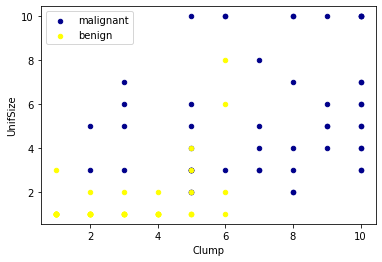

In [6]:
import matplotlib.pyplot as plt
ax = cell_df[cell_df['Class'] == 4][0:50].plot(kind='scatter', x='Clump', y='UnifSize', color='DarkBlue', label='malignant');
cell_df[cell_df['Class'] == 2][0:50].plot(kind='scatter', x='Clump', y='UnifSize', color='Yellow', label='benign', ax=ax);
plt.show()

<h2> Data pre-processing and selection</h2>

Lets first look at columns data types:

In [7]:
cell_df.dtypes

ID              int64
Clump           int64
UnifSize        int64
UnifShape       int64
MargAdh         int64
SingEpiSize     int64
BareNuc        object
BlandChrom      int64
NormNucl        int64
Mit             int64
Class           int64
dtype: object

It looks like the BareNuc column includes some values that are not numerical. We can drop those
rows:

In [8]:
cell_df = cell_df[pd.to_numeric(cell_df['BareNuc'], errors='coerce').notnull()]
cell_df['BareNuc'] = cell_df['BareNuc'].astype('int')
cell_df.dtypes

ID             int64
Clump          int64
UnifSize       int64
UnifShape      int64
MargAdh        int64
SingEpiSize    int64
BareNuc        int32
BlandChrom     int64
NormNucl       int64
Mit            int64
Class          int64
dtype: object

In [9]:
import numpy as np
feature_df = cell_df[['Clump', 'UnifSize', 'UnifShape', 'MargAdh','SingEpiSize', 'BareNuc', 'BlandChrom', 'NormNucl', 'Mit']]
X = np.asarray(feature_df)
X[0:5]

array([[ 5,  1,  1,  1,  2,  1,  3,  1,  1],
       [ 5,  4,  4,  5,  7, 10,  3,  2,  1],
       [ 3,  1,  1,  1,  2,  2,  3,  1,  1],
       [ 6,  8,  8,  1,  3,  4,  3,  7,  1],
       [ 4,  1,  1,  3,  2,  1,  3,  1,  1]], dtype=int64)

We want the model to predict the value of Class (that is, benign (=2) or malignant (=4)). As this
field can have one of only two possible values, we need to change its measurement level to reflect
this.

In [10]:
cell_df['Class'] = cell_df['Class'].astype('int')
y = np.asarray(cell_df['Class'])
y [0:5]

array([2, 2, 2, 2, 2])

<h2> 2.0 Train/Test dataset</h2>

<h2> 2.1  Modeling (SVM with Scikit-learn)</h2>

Okay, we split our dataset into train and test set:

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=4)
print ('Train set:', X_train.shape, y_train.shape)
print ('Test set:', X_test.shape, y_test.shape)

Train set: (546, 9) (546,)
Test set: (137, 9) (137,)


The SVM algorithm offers a choice of kernel functions for performing its processing. Basically,
mapping data into a higher dimensional space is called kernelling. The mathematical function used
for the transformation is known as the kernel function, and can be of different types, such as:
1.Linear
2.Polynomial
3.Radial basis function (RBF)
4.Sigmoid
Each of these functions has its characteristics, its pros and cons, and its equation, but as there’s
no easy way of knowing which function performs best with any given dataset, we usually choose
different functions in turn and compare the results. Let’s just use the default, RBF (Radial Basis
Function) for this lab.

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=4)
from sklearn import svm
clf = svm.SVC(kernel='poly')
clf.fit(X_train, y_train)

SVC(kernel='poly')

<b> After being fitted, the model can then be used to predict new values:</b>

In [13]:
yhat = clf.predict(X_test)
yhat [0:5]

array([2, 4, 2, 4, 2])

<h2> Evaluation</h2>

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools

In [15]:
def plot_confusion_matrix(cm, classes,
                        normalize=False,
                        title='Confusion matrix',
                        cmap=plt.cm.Blues):
    
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

              precision    recall  f1-score   support

           2       1.00      0.96      0.98        90
           4       0.92      1.00      0.96        47

    accuracy                           0.97       137
   macro avg       0.96      0.98      0.97       137
weighted avg       0.97      0.97      0.97       137

Confusion matrix, without normalization
[[86  4]
 [ 0 47]]


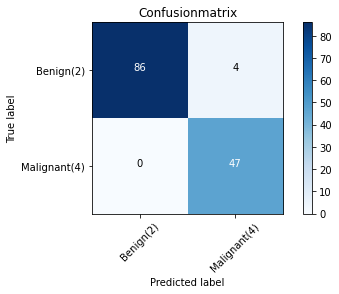

In [16]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, yhat, labels=[2,4])
np.set_printoptions(precision=2)
print (classification_report(y_test, yhat))

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Benign(2)','Malignant(4)'],normalize= False, title='Confusionmatrix')

<b> You can also easily use the f1_score from sklearn library:</b>

In [17]:
from sklearn.metrics import f1_score
f1_score(y_test, yhat, average='weighted')

0.9710669934861801

<b> Lets try jaccard index for accuracy:</b> 

In [18]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test, yhat, average='weighted')

0.9438958064977816

<h2> Practice</h2>

Can you rebuild the model, but this time with a linear kernel? You can use kernel=‘linear’
option, when you define the svm. How the accuracy changes with the new kernel function?

In [19]:
# write your code here
clf2 = svm.SVC(kernel='linear')
clf2.fit(X_train, y_train)
yhat2 = clf2.predict(X_test)
print("Avg F1-score: %.4f" % f1_score(y_test, yhat2, average='weighted'))
print("Jaccard score: %.4f" % jaccard_score(y_test, yhat2, average='weighted'))

Avg F1-score: 0.9639
Jaccard score: 0.9305


In [20]:
# write your code here
clf3 = svm.SVC(kernel='sigmoid')
clf3.fit(X_train, y_train)
yhat3 = clf2.predict(X_test)
print("Avg F1-score: %.4f" % f1_score(y_test, yhat3, average='weighted'))
print("Jaccard score: %.4f" % jaccard_score(y_test, yhat3, average='weighted'))

Avg F1-score: 0.9639
Jaccard score: 0.9305


<h2> Random Forest</h2>

In [21]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
#train model

clf4 = RandomForestClassifier(n_jobs=2, random_state=0)
clf4.fit(X_train, y_train)

RandomForestClassifier(n_jobs=2, random_state=0)

In [23]:
#create confusion matrix to gut check model

preds = clf4.predict(X_test)

pd.crosstab(y_test, preds, rownames=['Actual Result'], colnames=['Predicted Result'])

Predicted Result,2,4
Actual Result,,
2,86,4
4,0,47


In [24]:
from sklearn import metrics

In [25]:
from sklearn.metrics import confusion_matrix

In [26]:
yhat_tree=clf4.predict(X)
tree_jacc_test=metrics.jaccard_score(y, yhat_tree, average='micro')
tree_f1_test=metrics.f1_score(y, yhat_tree, average ='macro')
tree_precision_test=metrics.precision_score(y, yhat_tree, average ='macro')
tree_recall_test=metrics.recall_score(y, yhat_tree, average ='macro')
tree_accuracy_test=metrics.accuracy_score(y, yhat_tree)
tree_cnf_matrix = confusion_matrix(y, yhat_tree)
print("Jaccard Index is ", tree_jacc_test, " F1-score is" , tree_f1_test,"Precision is", tree_precision_test, "Recall is", tree_recall_test,"Actual is", tree_accuracy_test)
#print(classification_report(y, yhat_tree))
tree_cnf_matrix

Jaccard Index is  0.9883551673944687  F1-score is 0.9935881789677249 Precision is 0.9917695473251029 Recall is 0.9954954954954955 Actual is 0.9941434846266471


array([[440,   4],
       [  0, 239]], dtype=int64)

<h2>Reference:</h2> <b>Saeed Aghabozorgi, "Machine Learning" - IBM </b>

<h2> ACTIVITY 2</h2>

<B> You will use KNN (K-Nearest Neighbour classifier) to build and train a model using human cell records, and classify cells to whether the samples are benign or malignant</b>

In [27]:
from sklearn.neighbors import KNeighborsClassifier

<B> Training</b>

In [28]:
k = 4
#Train Model and Predict
neigh = KNeighborsClassifier(n_neighbors = k).fit(X_train,y_train)
neigh

KNeighborsClassifier(n_neighbors=4)

<b> Predicting</b>


In [29]:
yhat = neigh.predict(X_test)
yhat[0:5]

array([2, 4, 2, 4, 2])

<b> Accuracy evaluation</b>

In [30]:
from sklearn import metrics
print("Train set Accuracy: ", metrics.accuracy_score(y_train, neigh.predict(X_train)))
print("Test set Accuracy: ", metrics.accuracy_score(y_test, yhat))


Train set Accuracy:  0.9743589743589743
Test set Accuracy:  0.9708029197080292


<b>  Practice</b>

In [31]:
k = 6
neigh6 = KNeighborsClassifier(n_neighbors = k).fit(X_train,y_train)
yhat6 = neigh6.predict(X_test)
print("Train set Accuracy: ", metrics.accuracy_score(y_train, neigh6.predict(X_train)))
print("Test set Accuracy: ", metrics.accuracy_score(y_test, yhat6))

Train set Accuracy:  0.9798534798534798
Test set Accuracy:  0.9854014598540146


<b> We can calculate the accuracy of KNN for different Ks.</b>

In [32]:
import numpy as np
Ks = 10
mean_acc = np.zeros((Ks-1))
std_acc = np.zeros((Ks-1))
ConfustionMx = [];
for n in range(1,Ks):
    #Train Model and Predict
    neigh = KNeighborsClassifier(n_neighbors = n).fit(X_train,y_train)
    yhat=neigh.predict(X_test)
    mean_acc[n-1] = metrics.accuracy_score(y_test, yhat)
    std_acc[n-1]=np.std(yhat==y_test)/np.sqrt(yhat.shape[0])
mean_acc

array([0.98, 0.96, 0.97, 0.97, 0.97, 0.99, 0.99, 0.99, 0.97])

<b> Plot model accuracy for Different number of Neighbors</b>

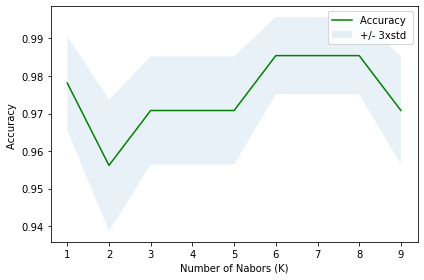

In [33]:
import matplotlib.pyplot as plt
plt.plot(range(1,Ks),mean_acc,'g')
plt.fill_between(range(1,Ks),mean_acc - 1 * std_acc,mean_acc + 1 * std_acc,alpha=0.10)
plt.legend(('Accuracy ', '+/- 3xstd'))
plt.ylabel('Accuracy ')
plt.xlabel('Number of Nabors (K)')
plt.tight_layout()
plt.show()

In [34]:
print( "The best accuracy was with", mean_acc.max(), "with k=", mean_acc.argmax()+1)

The best accuracy was with 0.9854014598540146 with k= 6


<b> Evaluation of the KNN classifier model </b>

In [35]:
knn=neigh.predict(X)
knn_jacc_test=metrics.jaccard_score(y, knn, average='micro')
knn_f1_test=metrics.f1_score(y, knn, average ='macro')
knn_precision_test=metrics.precision_score(y, knn, average ='macro')
knn_recall_test=metrics.recall_score(y, knn, average ='macro')
knn_accuracy_test=metrics.accuracy_score(y, knn)
knn_cnf_matrix = confusion_matrix(y, knn)
print("Jaccard Index is ", knn_jacc_test, " F1-score is" , knn_f1_test,"Precision is", knn_precision_test, "Recall is", knn_recall_test,"Actual is", knn_accuracy_test)
#print(classification_report(y, yhat_tree))
knn_cnf_matrix

Jaccard Index is  0.9514285714285714  F1-score is 0.9728260996758603 Precision is 0.9698889322989339 Recall is 0.9760262354404614 Actual is 0.9751098096632503


array([[432,  12],
       [  5, 234]], dtype=int64)

<h2> Logistic Regression Classifier </h2>

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
LR = LogisticRegression(C=0.01, solver='liblinear').fit(X_train,y_train)
LR

LogisticRegression(C=0.01, solver='liblinear')

In [37]:
yhatLR = LR.predict(X_test)
yhatLR


array([2, 4, 2, 4, 2, 2, 4, 2, 4, 2, 2, 4, 4, 4, 4, 2, 2, 2, 2, 2, 4, 2,
       4, 2, 2, 4, 2, 2, 4, 4, 4, 2, 4, 2, 2, 2, 4, 2, 2, 2, 2, 4, 2, 4,
       4, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 4, 4, 2, 2, 4,
       4, 2, 2, 2, 4, 4, 2, 4, 2, 4, 2, 2, 4, 4, 2, 2, 2, 2, 4, 4, 4, 4,
       2, 2, 4, 4, 2, 2, 2, 4, 2, 2, 4, 2, 2, 4, 2, 2, 4, 2, 4, 2, 2, 4,
       2, 2, 4, 2, 2, 2, 2, 2, 4, 4, 4, 2, 4, 2, 2, 4, 2, 2, 4, 2, 4, 2,
       2, 2, 2, 2, 4])

In [38]:
yhat_prob = LR.predict_proba(X_test)
yhat_prob[0:5]


array([[0.79, 0.21],
       [0.01, 0.99],
       [0.83, 0.17],
       [0.01, 0.99],
       [0.73, 0.27]])

<b> Evaluation</b>

In [39]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test, yhatLR, average='micro')


0.8513513513513513

In [48]:
def plot_confusion_matrix(cm, classes,
                        normalize=False,
                        title='Confusion matrix',
                        cmap=plt.cm.Blues):
    
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

              precision    recall  f1-score   support

           2       0.96      0.91      0.94        90
           4       0.85      0.94      0.89        47

    accuracy                           0.92       137
   macro avg       0.91      0.92      0.91       137
weighted avg       0.92      0.92      0.92       137

Confusion matrix, without normalization
[[82  8]
 [ 3 44]]


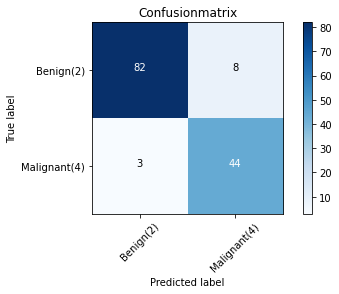

In [49]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, yhatLR, labels=[2,4])
np.set_printoptions(precision=2)
print (classification_report(y_test, yhatLR))

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Benign(2)','Malignant(4)'],normalize= False, title='Confusionmatrix')

<h2> Decision Trees Classifier</h2>

In [52]:
from sklearn.tree import DecisionTreeClassifier

In [53]:
# Create Entropy
cancerTree = DecisionTreeClassifier(criterion="entropy", max_depth = 4)
cancerTree # it shows the default parameters

DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [54]:
cancerTree.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

<h2> Prediction</h2>

In [56]:
cancerTree = cancerTree.predict(X_train)

In [57]:
print(cancerTree [0:5])
print(y_train [0:5])

[4 2 2 4 4]
[4 2 2 4 4]


<h2> Evaluation of DT</h2>

In [58]:
from sklearn import metrics

<h2> Visulaization</h2>

In [ ]:
#!conda install -c conda-forge pydotplus -y
#!conda install -c conda-forge python-graphviz -y

In [59]:
from six import StringIO

In [60]:
import pydotplus
import matplotlib.image as mpimg
from sklearn import tree
%matplotlib inline

<h2> Conclusion</h2>

<b>Which on is the best classifier ?</b>
